In [11]:
# paso 1:importar las librerías necesarias y cargar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Cargar el dataset
url = "https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv"
df_raw = pd.read_csv(url)

# Mostrar las primeras filas
print(df_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [12]:
# 2.Análisis Exploratorio de Datos (EDA)
# se eliminan columnas irrelevantes
# 'id', 'name', 'host_id', 'host_name' son etiquetas
df_processed = df_raw.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])

# hay valores nulos en el nuevo dataframe?
print("Valores nulos por columna:")
print(df_processed.isnull().sum())

# verificar el resumen estadístico de los precios
print("\nResumen de la columna Price:")
print(df_processed['price'].describe())

Valores nulos por columna:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Resumen de la columna Price:
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


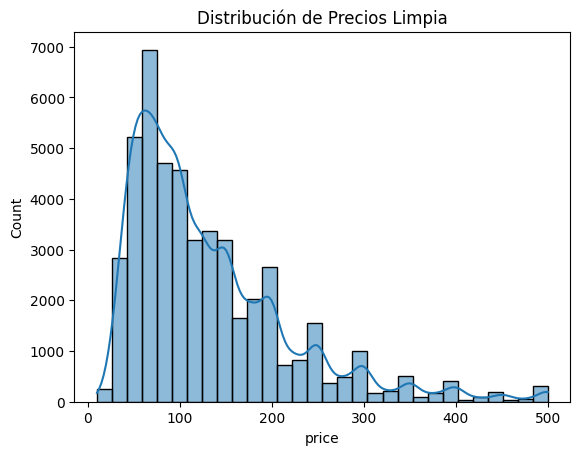

Set de entrenamiento: (38272, 10)
Set de prueba: (9568, 10)


In [13]:
# 2.1. Limpieza de datos faltantes 
# Como detectamos que hay 10,052 nulos en reviews_per_month, los llenamos con 0
df_processed['reviews_per_month'] = df_processed['reviews_per_month'].fillna(0)

# 2.2. Tratamiento de Outliers (Precios) 
# Según el resumen estadístico, hay precios de 0 y de 10,000. 
# Filtramos para quedarnos con un rango realista () entre 1 y 500)
df_processed = df_processed[(df_processed['price'] > 0) & (df_processed['price'] <= 500)]

# 2.3. Visualización rápida (encontré en internet que es recomendado para un EDA) 
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_processed['price'], bins=30, kde=True)
plt.title('Distribución de Precios Limpia')
plt.show()

#  2.4. División del dataset 
from sklearn.model_selection import train_test_split

# se separan las características (X) del objetivo (y)
X = df_processed.drop('price', axis=1)
y = df_processed['price']

# se dividen en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de entrenamiento: {X_train.shape}")
print(f"Set de prueba: {X_test.shape}")

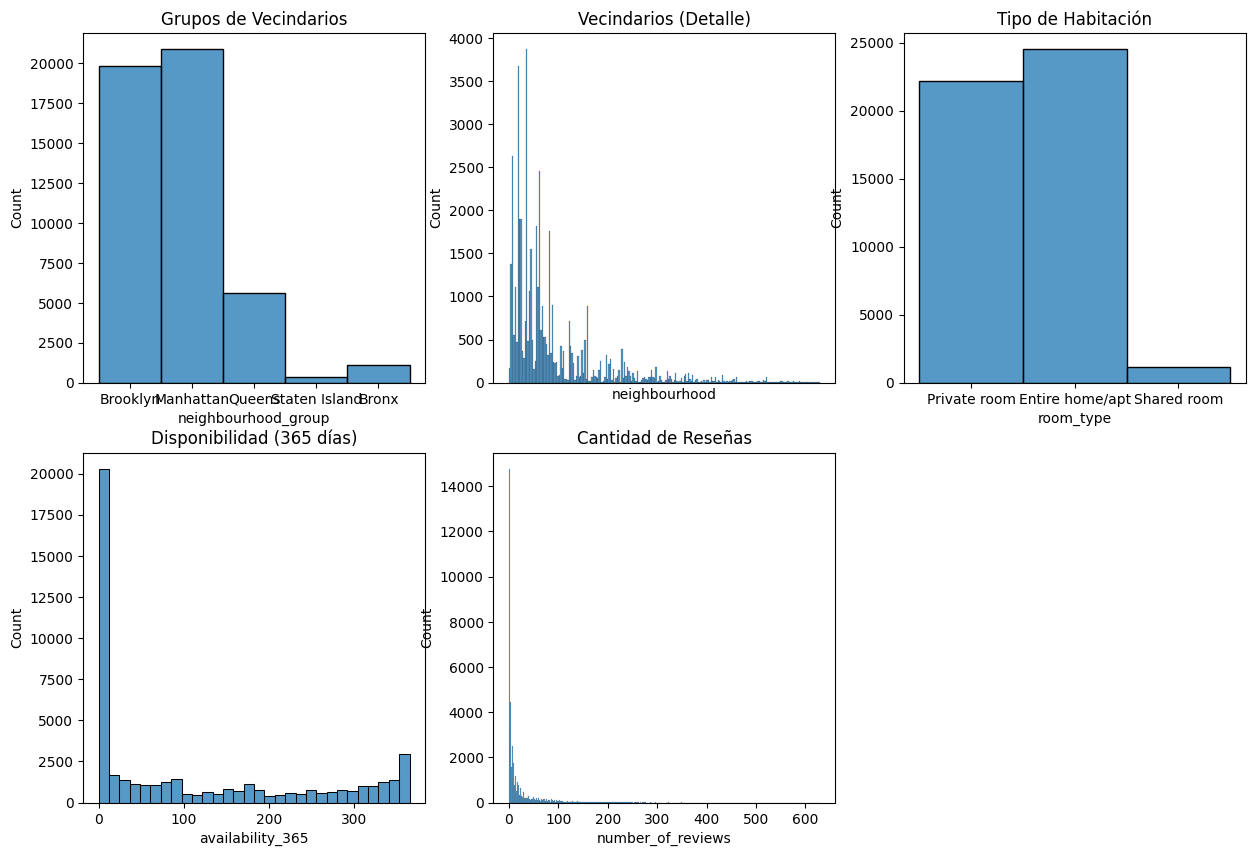

In [14]:
# Paso 3: Análisis de variables univariadas 
import matplotlib.pyplot as plt 
import seaborn as sns

# se crea una cuadrícula de 2 filas y 3 columnas
fig, axis = plt.subplots(2, 3, figsize=(15, 10))

# 1.distribucion de los grupos de vecindarios
sns.histplot(ax = axis[0,0], data = df_processed, x = "neighbourhood_group")
axis[0,0].set_title("Grupos de Vecindarios")

# 2. Vecindarios 
sns.histplot(ax = axis[0,1], data = df_processed, x = "neighbourhood").set_xticks([])
axis[0,1].set_title("Vecindarios (Detalle)")

# 3. Tipo de habitación
sns.histplot(ax = axis[0,2], data = df_processed, x = "room_type")
axis[0,2].set_title("Tipo de Habitación")

# 4. Disponibilidad al año
sns.histplot(ax = axis[1,0], data = df_processed, x = "availability_365")
axis[1,0].set_title("Disponibilidad (365 días)")

# 5. Número de reseñas 
sns.histplot(ax = axis[1,1], data = df_processed, x = "number_of_reviews")
axis[1,1].set_title("Cantidad de Reseñas")

# Ajustar diseño
plt.tight_layout

# Eliminamos el último espacio que sobra (fila 1, columna 2) me di cuenta que no tengo más variables categóricas para mostrar, así que elimino ese espacio vacío
fig.delaxes(axis[1, 2])

# Mostramos el gráfico
plt.show()




1. Grupos de Vecindarios: Se observa una dominancia de Brooklyn y Manhattan. Staten Island aparece como el grupo con menor representación, lo que indica que el mercado de Airbnb está fuertemente centralizado en las zonas más turísticas y densas de la ciudad.

2. Vecindarios: Aunque hay muchos barrios, el histograma muestra unos pocos picos muy altos, lo que sugiere que una pequeña cantidad de vecindarios específicos concentran la gran mayoría de la oferta.

3. Tipo de Habitación: La mayoría de las ofertas son Entire home/apt (Casas/Aptos enteros) o Private room (Habitaciones privadas). Las habitaciones compartidas (Shared rooms) casi no estan presentes en comparación, lo que refleja la preferencia de los usuarios por la privacidad.

4. Disponibilidad (365 días): Existe una distribución rara, hay un pico masivo cerca del 0 (alojamientos que casi nunca están disponibles) y otro pico menor cerca de 365 (alojamientos dedicados exclusivamente al alquiler vacacional todo el año).

5. Cantidad de Reseñas: La mayoría de los anuncios tienen pocas reseñas (concentradas cerca del 0).

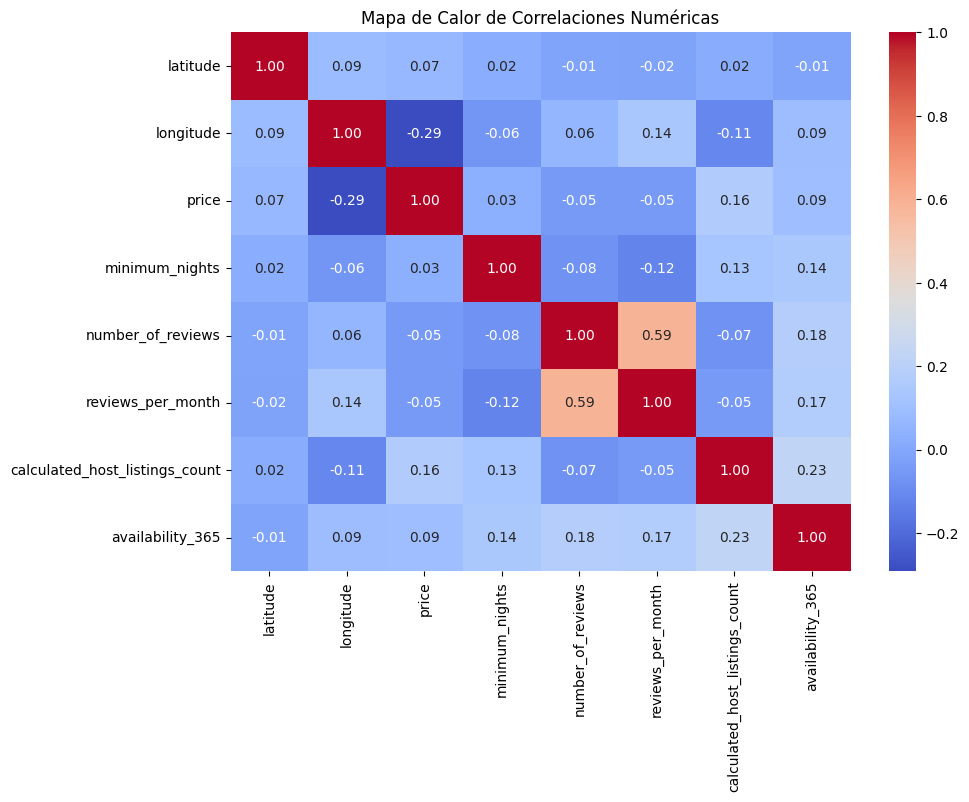

In [15]:
#analisis numerico-numerico
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(df_processed.select_dtypes(include=['float64', 'int64']).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de Calor de Correlaciones Numéricas")
plt.show()


/tmp/ipykernel_25617/2413777524.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axis[0], data=df_processed, x="neighbourhood_group", y="price", palette="viridis")
/tmp/ipykernel_25617/2413777524.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axis[1], data=df_processed, x="room_type", y="price", palette="magma")


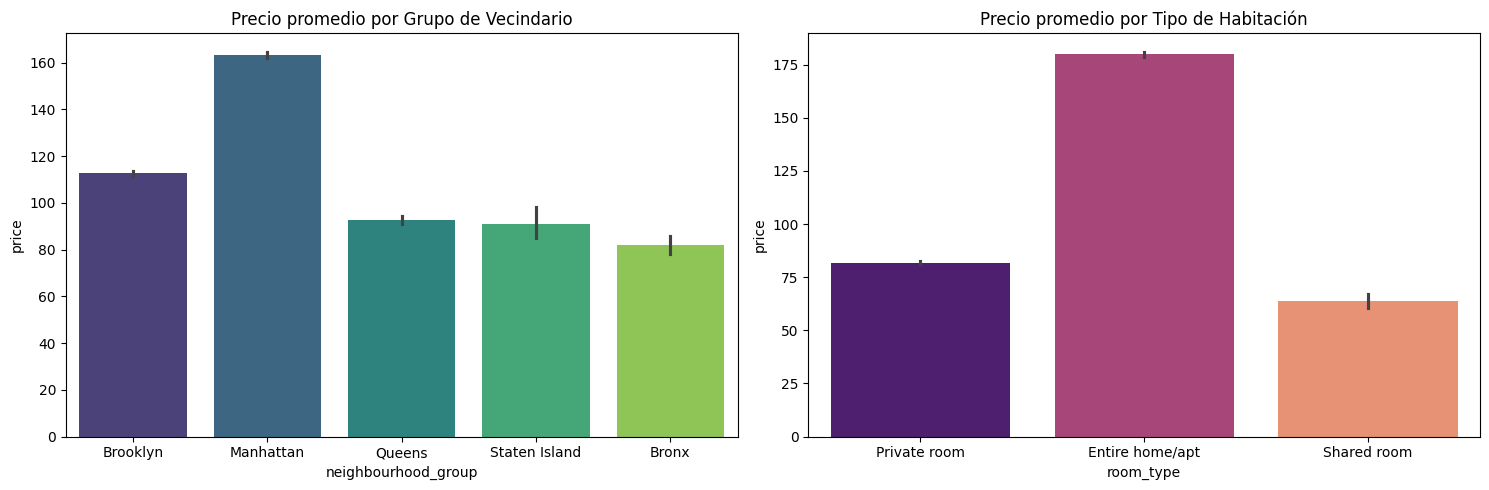

In [17]:
# analisis numerico-categorico
import matplotlib.pyplot as plt
import seaborn as sns
fig, axis = plt.subplots(1, 2, figsize=(15, 5))

# Precio vs Grupo de Vecindario
sns.barplot(ax=axis[0], data=df_processed, x="neighbourhood_group", y="price", palette="viridis")
axis[0].set_title("Precio promedio por Grupo de Vecindario")

# Precio vs Tipo de Habitación
sns.barplot(ax=axis[1], data=df_processed, x="room_type", y="price", palette="magma")
axis[1].set_title("Precio promedio por Tipo de Habitación")

plt.tight_layout()
plt.show()




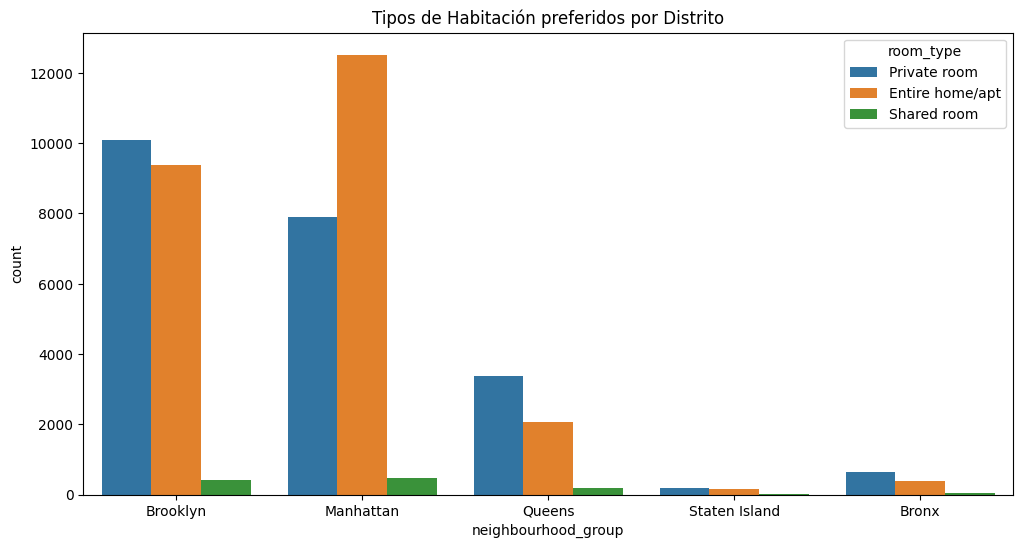

In [18]:
# analisis categorico-categorico
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df_processed, x="neighbourhood_group", hue="room_type")
plt.title("Tipos de Habitación preferidos por Distrito")
plt.show()

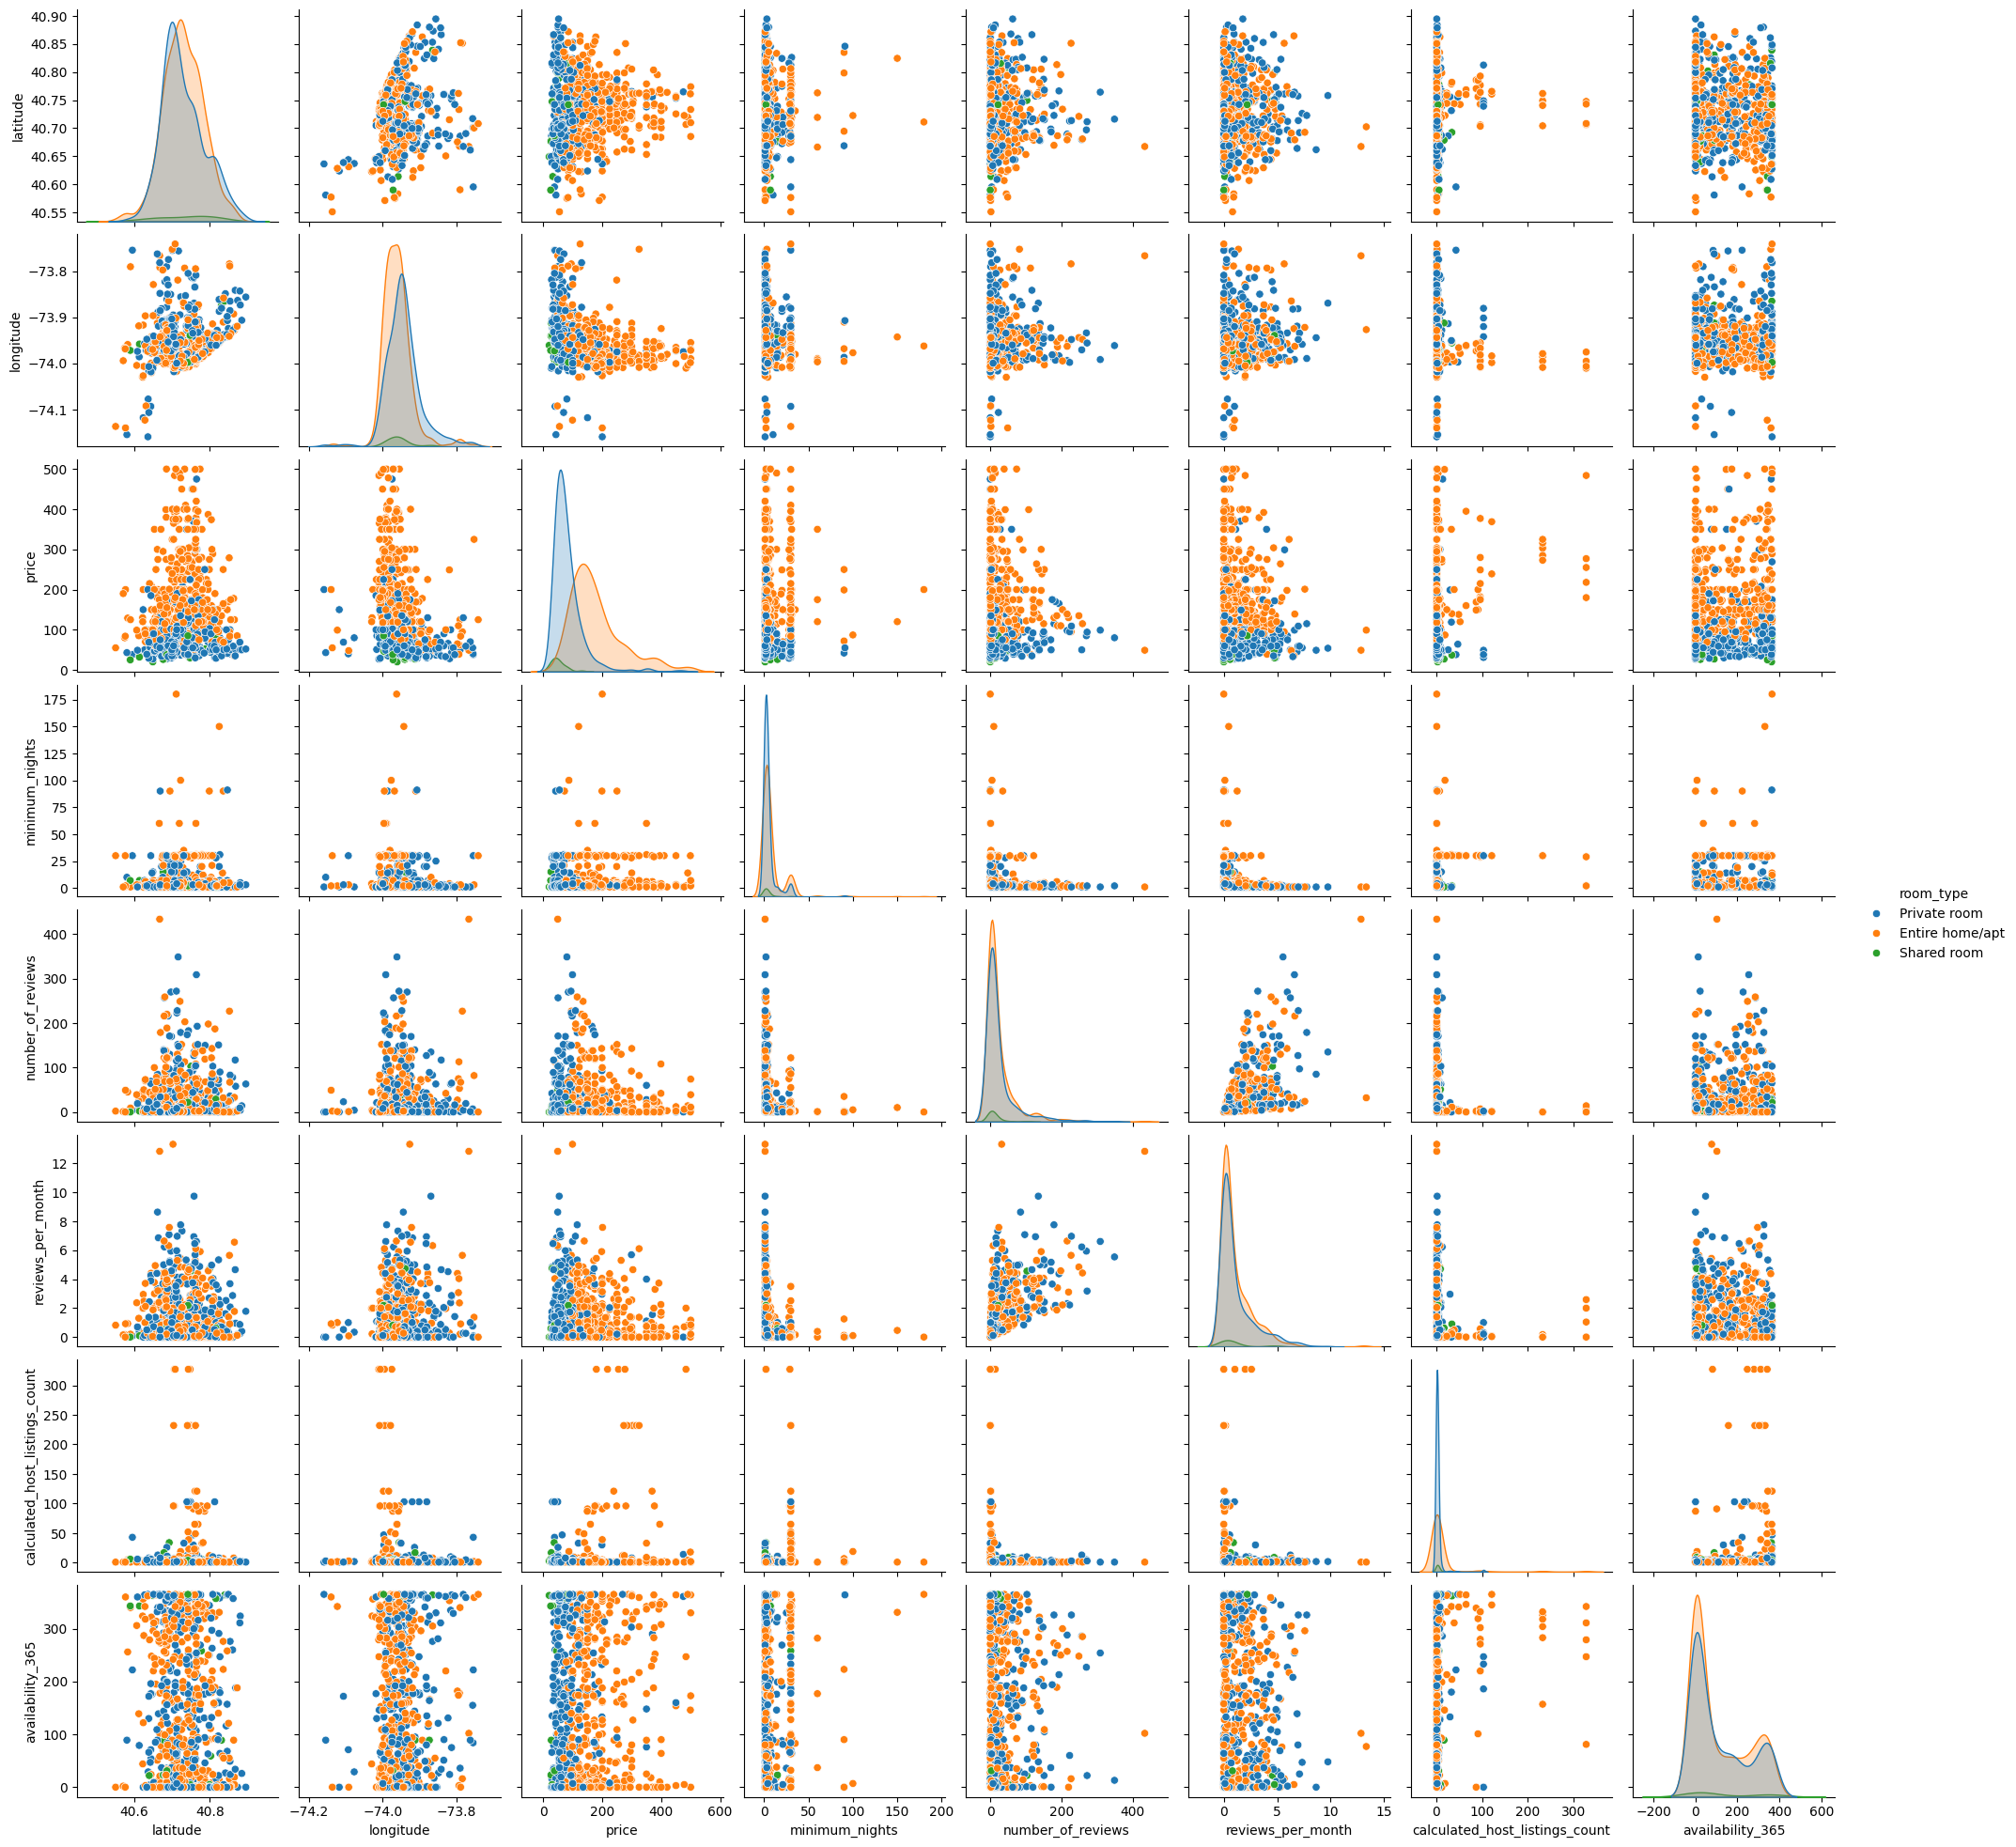

In [ ]:
# Analizar todo a la vez
sns.pairplot(data=df_processed.sample(1000), hue="room_type")
plt.show()